# SET UP

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)

# 1. Import Data

In [64]:
X_train = pd.read_csv('/content/drive/MyDrive/project/iris_prediction/Datasets/Processed/X_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/project/iris_prediction/Datasets/Processed/X_test.csv')
y_train = pd.read_csv('/content/drive/MyDrive/project/iris_prediction/Datasets/Processed/y_train.csv')
y_test = pd.read_csv('/content/drive/MyDrive/project/iris_prediction/Datasets/Processed/y_test.csv')

# 2. Data Transformation

## 2.1. Data Encoding

In [65]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

## 2.2. Data Scaling

In [66]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 2.3. Convert to Tensor

In [67]:
train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=64)

print(f'{len(train_dl)} batch per epoch')

4 batch per epoch


# 3. Build Model

In [68]:
class MLPClassifier(nn.Module):
    def __init__(self, in_features, h1, h2, out_features):
        super(MLPClassifier, self).__init__()

        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [69]:
model = MLPClassifier(4, 8, 8, 3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# 4. Training Model

In [70]:
def evaluation(dl):
    model.eval()
    correct, total, loss_sum = 0, 0, 0
    loss_sum = 0.0

    with torch.no_grad():
        for xb, yb in dl:
            logits = model(xb)

            loss_sum += criterion(logits, yb).item() * len(xb)

            y_pred = torch.argmax(logits, dim=1)
            correct += (y_pred == yb).sum().item()

            correct += (y_pred == yb).sum().item()
            total += len(xb)

    return loss_sum/total, correct/total

In [71]:
epochs = 100

learning_histories = {
    'train': [],
    'test': []
}
for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

    tr_loss, tr_acc = evaluation(train_dl)
    te_loss, te_acc = evaluation(test_dl)

    learning_histories['train'].append(tr_loss)
    learning_histories['test'].append(te_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1} | train loss {tr_loss} acc {tr_acc} | test loss {te_loss} acc {te_acc}')

Epoch 5 | train loss 0.8493963984342722 acc 1.3675213675213675 | test loss 0.9142935872077942 acc 1.2
Epoch 10 | train loss 0.4291784439840887 acc 1.7435897435897436 | test loss 0.500523567199707 acc 1.4666666666666666
Epoch 15 | train loss 0.20368712656518334 acc 1.8461538461538463 | test loss 0.27655646204948425 acc 1.6666666666666667
Epoch 20 | train loss 0.12760069463242832 acc 1.9487179487179487 | test loss 0.18095628917217255 acc 1.8666666666666667
Epoch 25 | train loss 0.06409898285682385 acc 1.9487179487179487 | test loss 0.10861167311668396 acc 1.9333333333333333
Epoch 30 | train loss 0.04944481079777082 acc 1.9658119658119657 | test loss 0.07928921282291412 acc 1.9333333333333333
Epoch 35 | train loss 0.04413098091275519 acc 1.9658119658119657 | test loss 0.07336559891700745 acc 1.9333333333333333
Epoch 40 | train loss 0.04411489688035133 acc 1.9658119658119657 | test loss 0.07212238758802414 acc 1.9333333333333333
Epoch 45 | train loss 0.04097520139737007 acc 1.9658119658119

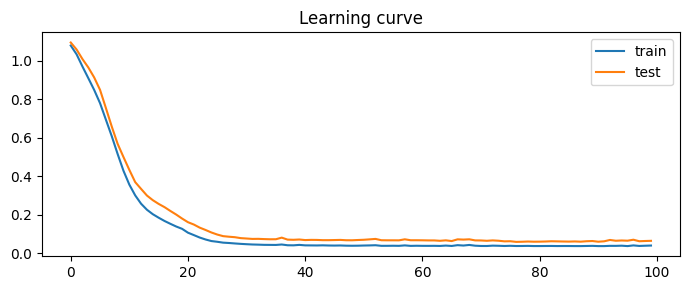

In [72]:
plt.figure(figsize=(7, 3))
plt.plot(learning_histories["train"], label="train")
plt.plot(learning_histories["test"], label="test")
plt.legend()
plt.title("Learning curve")
plt.tight_layout()
plt.show()